# Pre Processing

In [1]:
# =============================
# 1. IMPORT LIBRARIES
# =============================
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


# Download required NLTK resources (run once)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [2]:
df = pd.read_csv("/content/mental_health.csv")   # adjust path if needed
print(df)
# Keep only required columns
df = df[['text', 'label']]

                                                    text  label
0      dear american teens question dutch person hear...      0
1      nothing look forward lifei dont many reasons k...      1
2      music recommendations im looking expand playli...      0
3      im done trying feel betterthe reason im still ...      1
4      worried  year old girl subject domestic physic...      1
...                                                  ...    ...
27972  posting everyday people stop caring  religion ...      0
27973  okay definetly need hear guys opinion ive pret...      0
27974  cant get dog think ill kill myselfthe last thi...      1
27975  whats point princess bridei really think like ...      1
27976  got nudes person might might know snapchat do ...      0

[27977 rows x 2 columns]


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27977 entries, 0 to 27976
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    27977 non-null  object
 1   label   27977 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 437.3+ KB


In [4]:
# Drop missing values
df.dropna(inplace=True)

# =============================
# 3. INITIALIZE NLP TOOLS
# =============================
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# =============================
# 4. TEXT CLEANING FUNCTION
# =============================
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    tokens = text.split()

    # Remove stopwords & lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    # Join tokens back to string
    return " ".join(tokens)

# =============================
# 5. APPLY PREPROCESSING
# =============================
df['clean_text'] = df['text'].apply(preprocess_text)

# =============================
# 6. CHECK RESULT
# =============================
print(df[['text', 'clean_text', 'label']].head())


                                                text  \
0  dear american teens question dutch person hear...   
1  nothing look forward lifei dont many reasons k...   
2  music recommendations im looking expand playli...   
3  im done trying feel betterthe reason im still ...   
4  worried  year old girl subject domestic physic...   

                                          clean_text  label  
0  dear american teen question dutch person heard...      0  
1  nothing look forward lifei dont many reason ke...      1  
2  music recommendation im looking expand playlis...      0  
3  im done trying feel betterthe reason im still ...      1  
4  worried year old girl subject domestic physica...      1  


In [5]:
df['label'].value_counts()


,count
label,
0,14139
1,13838


In [6]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (22381,)
Test size: (5596,)


# Using Bag Of Words

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3
)

# Fit ONLY on training data
X_train_bow = bow_vectorizer.fit_transform(X_train)

# Transform test data
X_test_bow = bow_vectorizer.transform(X_test)

print("BoW Train Shape:", X_train_bow.shape)
print("BoW Test Shape:", X_test_bow.shape)


BoW Train Shape: (22381, 10000)
BoW Test Shape: (5596, 10000)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
model_bow = LogisticRegression(max_iter=1000)
model_bow.fit(X_train_bow, y_train)

y_pred_bow = model_bow.predict(X_test_bow)
print("BoW Results:\n", classification_report(y_test, y_pred_bow))
print("confusion_matrix:\n", confusion_matrix(y_test, y_pred_bow))


BoW Results:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91      2828
           1       0.92      0.89      0.90      2768

    accuracy                           0.91      5596
   macro avg       0.91      0.91      0.91      5596
weighted avg       0.91      0.91      0.91      5596

confusion_matrix:
 [[2619  209]
 [ 309 2459]]


# Using TF-IDF

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3
)

# Fit ONLY on training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF Train Shape:", X_train_tfidf.shape)
print("TF-IDF Test Shape:", X_test_tfidf.shape)


TF-IDF Train Shape: (22381, 10000)
TF-IDF Test Shape: (5596, 10000)


In [10]:
from sklearn.metrics import classification_report
model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
print("confusion_matrix:\n", confusion_matrix(y_test, y_pred_bow))
print("TF-IDF Results:\n", classification_report(y_test, y_pred_tfidf))


confusion_matrix:
 [[2619  209]
 [ 309 2459]]
TF-IDF Results:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92      2828
           1       0.93      0.91      0.92      2768

    accuracy                           0.92      5596
   macro avg       0.92      0.92      0.92      5596
weighted avg       0.92      0.92      0.92      5596



In [11]:
def predict_text(sentence):
    # Preprocess sentence using SAME preprocessing
    clean_sentence = preprocess_text(sentence)

    # Vectorize using TRAINED TF-IDF
    sentence_tfidf = tfidf_vectorizer.transform([clean_sentence])

    # Predict
    prediction = model_tfidf.predict(sentence_tfidf)[0]
    probability =model_tfidf.predict_proba(sentence_tfidf)[0][1]

    return prediction, probability


In [12]:
sentences = [
    "I feel happy and motivated today",
    "I don't want to live anymore",
    "Nothing makes sense and I feel empty",
    "I am excited about my future"
]

for s in sentences:
    pred, prob = predict_text(s)
    print(f"Text: {s}")
    print(f"Prediction: {pred} | Probability (class 1): {prob:.2f}\n")


Text: I feel happy and motivated today
Prediction: 0 | Probability (class 1): 0.30

Text: I don't want to live anymore
Prediction: 1 | Probability (class 1): 0.91

Text: Nothing makes sense and I feel empty
Prediction: 0 | Probability (class 1): 0.45

Text: I am excited about my future
Prediction: 0 | Probability (class 1): 0.14



# Linear SVC --TF IDF

In [13]:
from sklearn.svm import LinearSVC
# =========================
# LINEAR SVM MODEL (BEST BASELINE)
# =========================
svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced"
)

svm_model.fit(X_train_tfidf, y_train)

# =========================
# EVALUATION
# =========================
y_pred = svm_model.predict(X_test_tfidf)

print("\nTF-IDF + LINEAR SVM RESULTS:\n")
print(classification_report(y_test, y_pred))

# =========================
# PREDICTION FUNCTION
# =========================
def predict_text(sentence):
    clean_sentence = preprocess_text(sentence)
    vec = tfidf_vectorizer.transform([clean_sentence])
    prediction = svm_model.predict(vec)[0]
    return prediction

# =========================
# TEST SENTENCES
# =========================
sentences = [
    "I feel happy and motivated today",
    "I don't want to live anymore",
    "Nothing makes sense and I feel empty",
    "I am excited about my future",
    "I feel hopeless and tired of everything"
]

print("\nPREDICTIONS:\n")
for s in sentences:
    print(f"Text: {s}")
    print(f"Prediction: {predict_text(s)}\n")



TF-IDF + LINEAR SVM RESULTS:

              precision    recall  f1-score   support

           0       0.91      0.92      0.91      2828
           1       0.92      0.90      0.91      2768

    accuracy                           0.91      5596
   macro avg       0.91      0.91      0.91      5596
weighted avg       0.91      0.91      0.91      5596


PREDICTIONS:

Text: I feel happy and motivated today
Prediction: 0

Text: I don't want to live anymore
Prediction: 1

Text: Nothing makes sense and I feel empty
Prediction: 0

Text: I am excited about my future
Prediction: 0

Text: I feel hopeless and tired of everything
Prediction: 1



# Word2Vec -Logistic

In [14]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 71.2 MB/s eta 0:00:00


In [15]:
from nltk.tokenize import word_tokenize
from sklearn.metrics import classification_report
X_train_tokens = X_train.apply(lambda x: x.split())
X_test_tokens = X_test.apply(lambda x: x.split())
from gensim.models import Word2Vec
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1   # Skip-gram
)
import numpy as np

def sentence_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)
X_train_w2v = np.array([
    sentence_vector(tokens, w2v_model)
    for tokens in X_train_tokens
])

X_test_w2v = np.array([
    sentence_vector(tokens, w2v_model)
    for tokens in X_test_tokens
])

print("Train W2V shape:", X_train_w2v.shape)
print("Test W2V shape:", X_test_w2v.shape)
from sklearn.linear_model import LogisticRegression

model_w2v = LogisticRegression(max_iter=1000)
model_w2v.fit(X_train_w2v, y_train)
from sklearn.metrics import classification_report

y_pred_w2v = model_w2v.predict(X_test_w2v)
print("confusion_matrix:\n", confusion_matrix(y_test, y_pred_bow))
print(classification_report(y_test, y_pred_w2v))


Train W2V shape: (22381, 100)
Test W2V shape: (5596, 100)
confusion_matrix:
 [[2619  209]
 [ 309 2459]]
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      2828
           1       0.88      0.93      0.90      2768

    accuracy                           0.90      5596
   macro avg       0.90      0.90      0.90      5596
weighted avg       0.90      0.90      0.90      5596



# Word2vec--Linear SVC

In [16]:
from gensim.models import Word2Vec
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report
# Tokenize text
X_train_tokens = X_train.apply(str.split)
X_test_tokens = X_test.apply(str.split)

# Train Word2Vec (Skip-gram)
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

# Convert sentence → vector (mean pooling)
def sentence_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

X_train_w2v = np.array([sentence_vector(t, w2v_model) for t in X_train_tokens])
X_test_w2v = np.array([sentence_vector(t, w2v_model) for t in X_test_tokens])

# Train Linear SVC
w2v_svc = LinearSVC(
    C=1.0,
    class_weight="balanced"
)

w2v_svc.fit(X_train_w2v, y_train)

# Evaluate
y_pred_w2v = w2v_svc.predict(X_test_w2v)
print("confusion_matrix:\n", confusion_matrix(y_test, y_pred_bow))
print(classification_report(y_test, y_pred_w2v))


confusion_matrix:
 [[2619  209]
 [ 309 2459]]
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      2828
           1       0.88      0.93      0.91      2768

    accuracy                           0.90      5596
   macro avg       0.91      0.90      0.90      5596
weighted avg       0.91      0.90      0.90      5596



In [17]:
!pip install -q tensorflow nltk scikit-learn pandas numpy

In [18]:
# =========================
# INSTALL
# =========================
!pip install -q tensorflow nltk scikit-learn pandas numpy

# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import re, string, nltk
from nltk.corpus import stopwords
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, GRU, Dense, Dropout,
    Bidirectional, Conv1D, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# NLTK
# =========================
nltk.download('stopwords')

# =========================
# LOAD DATASET
# =========================
df = pd.read_csv("/content/mental_health.csv")
df = df[['text', 'label']].dropna()

# Ensure labels are integers
df['label'] = df['label'].astype(int)

# =========================
# TEXT CLEANING
# =========================
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return ' '.join(w for w in text.split() if w not in stop_words)

df['text'] = df['text'].apply(clean_text)

# =========================
# PREPARE DATA
# =========================
MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])

X = pad_sequences(tokenizer.texts_to_sequences(df['text']), maxlen=MAX_LEN)
y = df['label'].values

num_classes = len(np.unique(y))
class_names = [str(i) for i in range(num_classes)]

# =========================
# TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# TRAIN & EVALUATE
# =========================
def train_and_evaluate(model, name):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[es],
        verbose=1
    )

    preds = np.argmax(model.predict(X_test), axis=1)

    print(f"\n{name} Accuracy: {accuracy_score(y_test, preds):.4f}")

    print(classification_report(y_test, preds, target_names=class_names))

    print("confusion_matrix:\n", confusion_matrix(y_test, preds))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Epoch 1/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.9442 - loss: 0.1651 - val_accuracy: 0.9158 - val_loss: 0.2156
Epoch 2/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9624 - loss: 0.1100 - val_accuracy: 0.9136 - val_loss: 0.2553
Epoch 3/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.9726 - loss: 0.0820 - val_accuracy: 0.9127 - val_loss: 0.2856
Epoch 4/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9820 - loss: 0.0576 - val_accuracy: 0.9004 - val_loss: 0.3138
Epoch 5/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9860 - loss: 0.0412 - val_accuracy: 0.9095 - val_loss: 0.3344
Epoch 6/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9907 - loss: 0.0290 - val_accuracy: 0.8999 - val_loss: 0.3655
Epoch 7/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9912 - loss: 0.0295 - val_accuracy: 0.8952 - val_loss: 0.4076
Epoch 8/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9902 - loss: 0.0288 - 

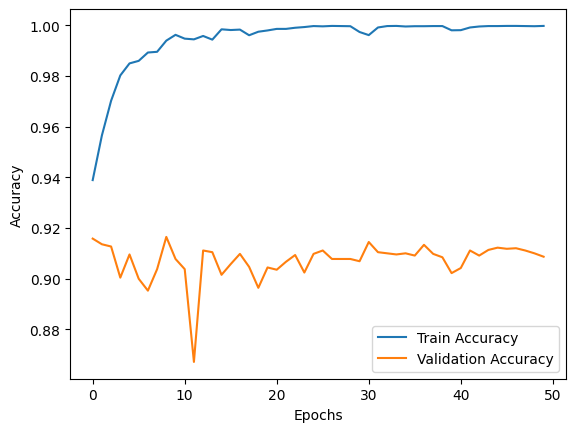

In [32]:
# ===== TRAIN + SAVE HISTORY + PLOT (ALL TOGETHER) =====

import matplotlib.pyplot as plt

history = bilstm.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [33]:
# =========================
# MODELS
# =========================

lstm = Sequential([
    Embedding(MAX_WORDS, 256, input_length=MAX_LEN),

    LSTM(128, return_sequences=True),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

train_and_evaluate(lstm, "Deep LSTM")



Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


560/560 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.8429 - loss: 0.3704 - val_accuracy: 0.9151 - val_loss: 0.2161
Epoch 2/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9465 - loss: 0.1553 - val_accuracy: 0.8981 - val_loss: 0.2359
Epoch 3/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9632 - loss: 0.1097 - val_accuracy: 0.9113 - val_loss: 0.2406
Epoch 4/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.9779 - loss: 0.0712 - val_accuracy: 0.9080 - val_loss: 0.3234
Epoch 5/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9853 - loss: 0.0454 - val_accuracy: 0.9080 - val_loss: 0.3280
Epoch 6/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9916 - loss: 0.0306 - val_accuracy: 0.9033 - val_loss: 0.4232
Epoch 7/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9863 - loss: 0.0421 - val_accuracy: 0.8999 - val_loss: 0.3798
Epoch 8/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.9902 - loss: 0.0283 - val_accurac

In [20]:
# BiLSTM (BEST)
bilstm = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(128)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
train_and_evaluate(bilstm, "BiLSTM")



Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


560/560 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8124 - loss: 0.3886 - val_accuracy: 0.9189 - val_loss: 0.2191
Epoch 2/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9473 - loss: 0.1523 - val_accuracy: 0.9207 - val_loss: 0.2291
Epoch 3/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9626 - loss: 0.1128 - val_accuracy: 0.9133 - val_loss: 0.2557
Epoch 4/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9732 - loss: 0.0799 - val_accuracy: 0.9084 - val_loss: 0.3258
Epoch 5/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9723 - loss: 0.0783 - val_accuracy: 0.9127 - val_loss: 0.2889
Epoch 6/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9815 - loss: 0.0559 - val_accuracy: 0.9120 - val_loss: 0.3624
Epoch 7/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9873 - loss: 0.0409 - val_accuracy: 0.9156 - val_loss: 0.3765
Epoch 8/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9895 - loss: 0.0309 - val_accurac

In [21]:
# GRU
gru = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    GRU(128),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
train_and_evaluate(gru, "GRU")



Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


560/560 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8249 - loss: 0.3875 - val_accuracy: 0.9122 - val_loss: 0.2454
Epoch 2/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9469 - loss: 0.1464 - val_accuracy: 0.9127 - val_loss: 0.2148
Epoch 3/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9701 - loss: 0.0861 - val_accuracy: 0.9151 - val_loss: 0.2511
Epoch 4/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9840 - loss: 0.0457 - val_accuracy: 0.9044 - val_loss: 0.2974
Epoch 5/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.9889 - loss: 0.0339 - val_accuracy: 0.9042 - val_loss: 0.3204
Epoch 6/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9906 - loss: 0.0285 - val_accuracy: 0.9084 - val_loss: 0.3445
Epoch 7/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9931 - loss: 0.0199 - val_accuracy: 0.8988 - val_loss: 0.4688
Epoch 8/50
560/560 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.9938 - loss: 0.0202 - val_accuracy: 0.9

In [22]:
# =========================
# PREDICTION FUNCTION
# =========================
def predict_text(text, model):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN)
    return np.argmax(model.predict(pad), axis=1)[0]

# Example
print("\nPrediction:", predict_text("I feel anxious and depressed", bilstm))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

Prediction: 1


In [34]:
import pickle

# Save trained model
pickle.dump(svm_model, open("model.pkl", "wb"))

# Save TF-IDF vectorizer
pickle.dump(tfidf_vectorizer, open("vectorizer.pkl", "wb"))

print("model.pkl and vectorizer.pkl saved successfully")


model.pkl and vectorizer.pkl saved successfully
